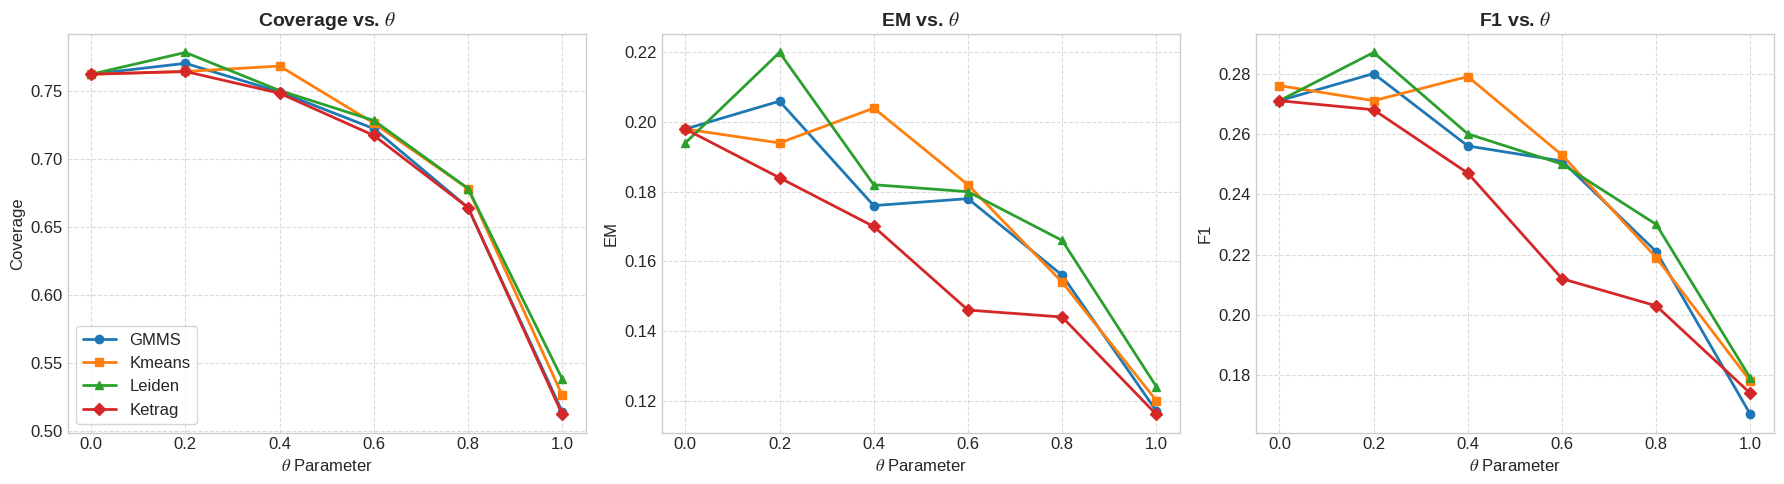

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 数据录入 (根据你提供的图片)
# X轴: Theta 参数
theta = [0, 0.2, 0.4, 0.6, 0.8, 1.0]

# 不同方法的实验数据
data = {
    'GMMS': {
        'Coverage': [0.7620, 0.7700, 0.7490, 0.7220, 0.6640, 0.5140],
        'EM':       [0.198, 0.206, 0.176, 0.178, 0.156, 0.117],
        'F1':       [0.271, 0.280, 0.256, 0.251, 0.221, 0.167]
    },
    'Kmeans': {
        'Coverage': [0.7620, 0.7640, 0.7680, 0.7260, 0.6780, 0.5260],
        'EM':       [0.198, 0.194, 0.204, 0.182, 0.154, 0.120],
        'F1':       [0.276, 0.271, 0.279, 0.253, 0.219, 0.178]
    },
    'Leiden': {
        'Coverage': [0.7620, 0.7780, 0.7500, 0.7280, 0.6780, 0.5380],
        'EM':       [0.194, 0.220, 0.182, 0.180, 0.166, 0.124],
        'F1':       [0.271, 0.287, 0.260, 0.250, 0.230, 0.179]
    },
    'Ketrag': {
        'Coverage': [0.7620, 0.7640, 0.7480, 0.7170, 0.6640, 0.5120],
        'EM':       [0.198, 0.184, 0.170, 0.146, 0.144, 0.116],
        'F1':       [0.271, 0.268, 0.247, 0.212, 0.203, 0.174]
    }
}

# 2. 设置绘图风格
plt.style.use('seaborn-v0_8-whitegrid') # 使用清晰的网格风格
metrics = ['Coverage', 'EM', 'F1']
markers = ['o', 's', '^', 'D'] # 不同方法使用不同的标记点
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'] # 自定义颜色

# 3. 创建画布 (1行3列，分别对应三个指标)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 4. 循环绘制每个指标的子图
for i, metric_name in enumerate(metrics):
    ax = axes[i]
    metric_key = metric_name # 数据字典中的键名
    
    # 在当前子图中绘制每种方法的曲线
    for j, (method_name, method_data) in enumerate(data.items()):
        ax.plot(theta, method_data[metric_key], 
                marker=markers[j], 
                linewidth=2, 
                markersize=6, 
                label=method_name,
                color=colors[j])
    
    # 子图装饰
    ax.set_title(f'{metric_name} vs. $\\theta$', fontsize=14, fontweight='bold')
    ax.set_xlabel(r'$\theta$ Parameter', fontsize=12)
    ax.set_ylabel(metric_name, fontsize=12)
    ax.set_xticks(theta) # 强制显示所有X轴刻度
    ax.grid(True, linestyle='--', alpha=0.7)
    
    # 只在第一个图或者最后一个图显示图例，避免遮挡
    if i == 0:
        ax.legend(loc='lower left', frameon=True)

# 5. 整体布局调整
plt.tight_layout()
# plt.suptitle('Performance Comparison of RAG Strategies over $\\theta$', fontsize=16, y=1.05)

# 6. 显示或保存
plt.savefig('result_line_chart_theta.pdf', bbox_inches='tight')
plt.show()

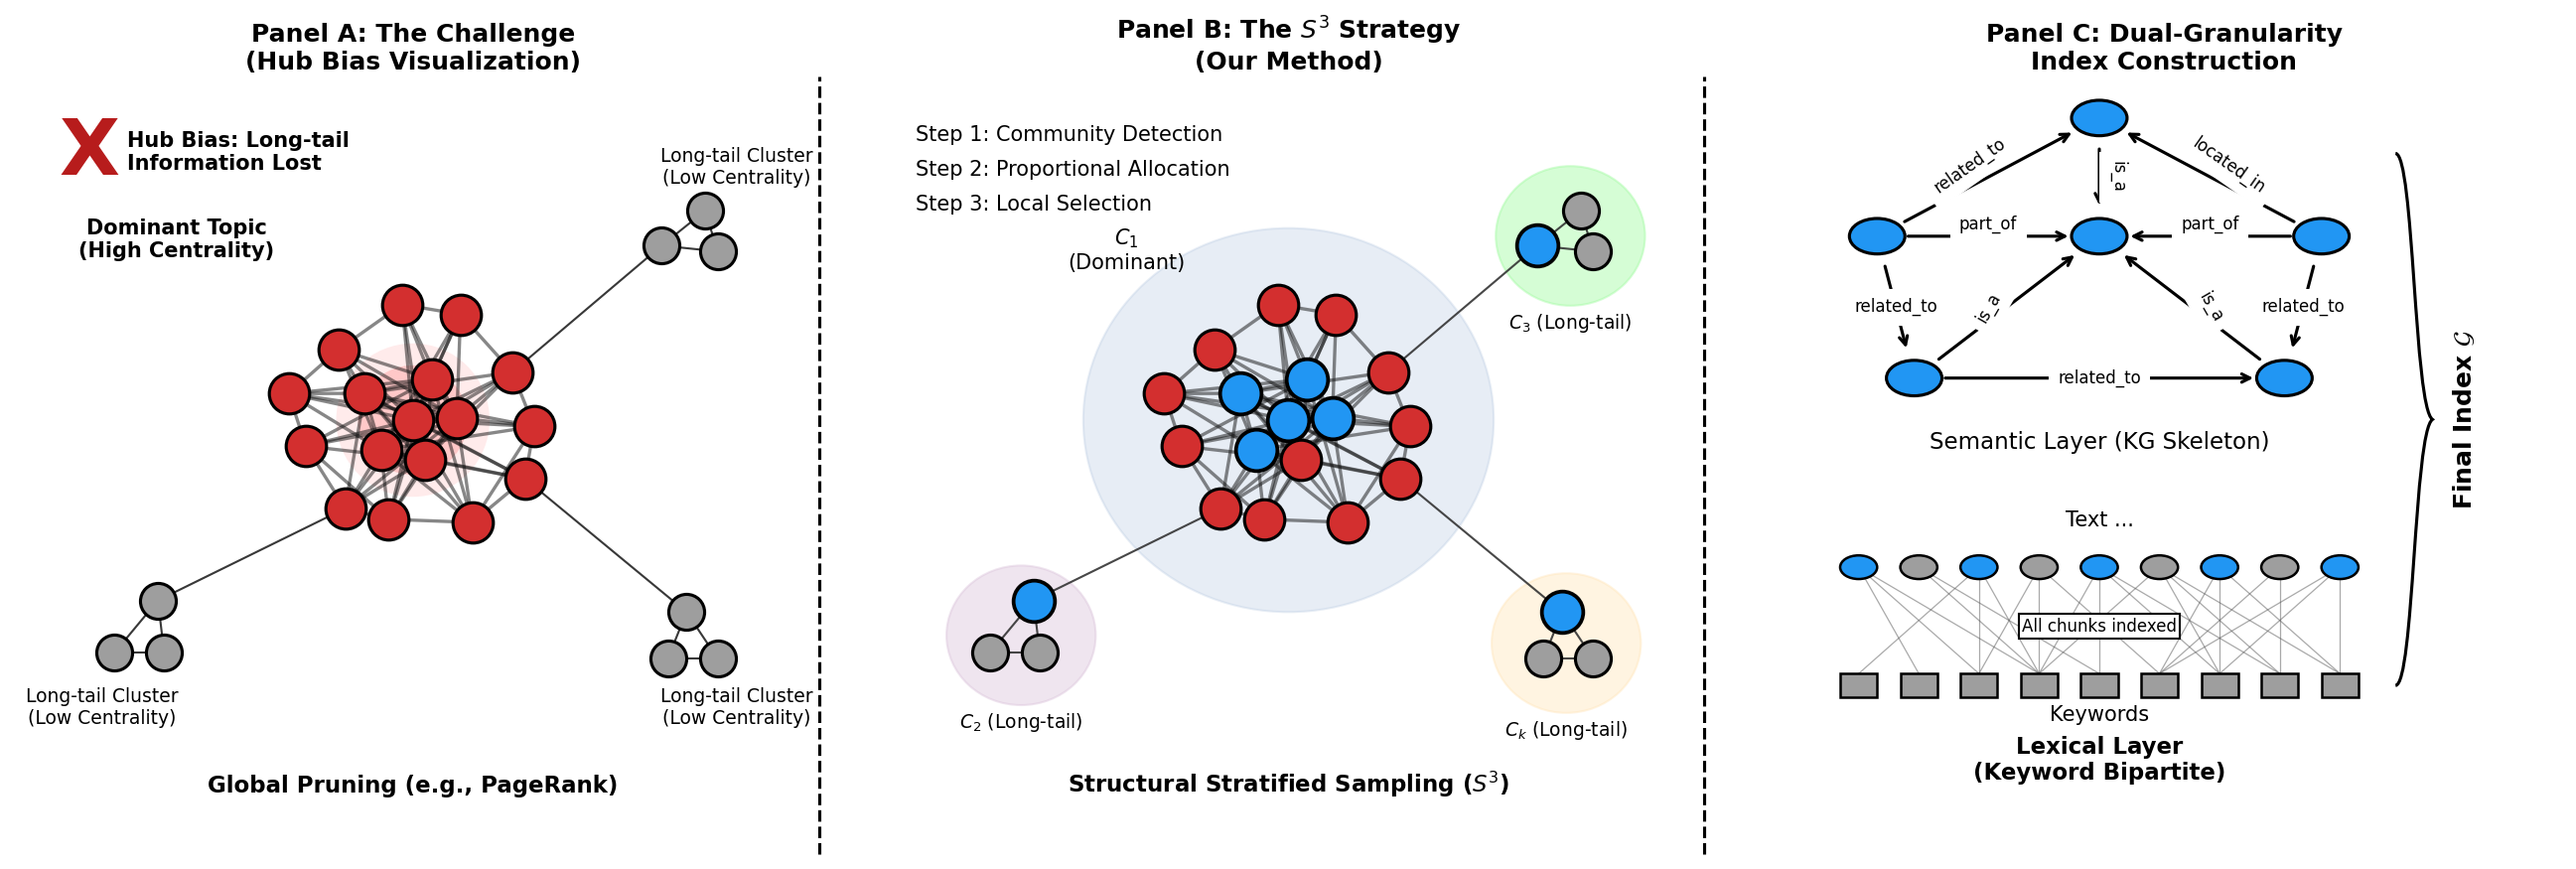

In [1]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.lines as lines
import networkx as nx
import numpy as np
import random
from matplotlib.path import Path

# 设置绘图风格
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']

# ==========================================
# 拓扑生成与 Panel A, B 绘图函数 (完全保持原样)
# ==========================================
def get_perfect_hairball_topology():
    G = nx.Graph()
    pos = {}
    random.seed(42) 
    
    hub = 0
    pos[hub] = np.array([0.0, 0.0])
    num_inner = 5
    inner_nodes = list(range(1, num_inner + 1))
    num_outer = 11
    outer_nodes = list(range(num_inner + 1, num_inner + num_outer + 1))
    
    for i, n in enumerate(inner_nodes):
        angle = (2 * np.pi / num_inner) * i + random.uniform(-0.2, 0.2)
        r = random.uniform(0.35, 0.5) 
        pos[n] = np.array([np.cos(angle)*r, np.sin(angle)*r])
        
    for i, n in enumerate(outer_nodes):
        angle = (2 * np.pi / num_outer) * i + random.uniform(-0.1, 0.1)
        r = random.uniform(0.85, 1.1) 
        pos[n] = np.array([np.cos(angle)*r, np.sin(angle)*r])
        
    all_center = [hub] + inner_nodes + outer_nodes
    G.add_nodes_from(all_center)
    
    for n in inner_nodes + outer_nodes:
        G.add_edge(hub, n)
    import itertools
    for u, v in itertools.combinations(inner_nodes, 2):
        G.add_edge(u, v)
    for out_n in outer_nodes:
        targets = random.sample(inner_nodes, k=random.randint(3, 4))
        for t in targets:
            G.add_edge(out_n, t)
    for i in range(num_outer):
        u = outer_nodes[i]
        v = outer_nodes[(i+1) % num_outer]
        G.add_edge(u, v)
        if random.random() > 0.6:
            v2 = outer_nodes[(i+2) % num_outer]
            G.add_edge(u, v2)

    start_id = max(all_center) + 1
    c2_nodes = [start_id, start_id+1, start_id+2]
    base_c2 = np.array([-2.2, -1.9]) 
    pos[c2_nodes[0]] = base_c2 + [0.15, 0.35]
    pos[c2_nodes[1]] = base_c2 + [-0.2, -0.1]
    pos[c2_nodes[2]] = base_c2 + [0.2, -0.1]
    c3_nodes = [start_id+3, start_id+4, start_id+5]
    base_c3 = np.array([2.2, 1.6])
    pos[c3_nodes[0]] = base_c3 + [-0.2, -0.1]
    pos[c3_nodes[1]] = base_c3 + [0.15, 0.2]
    pos[c3_nodes[2]] = base_c3 + [0.25, -0.15]
    ck_nodes = [start_id+6, start_id+7, start_id+8]
    base_ck = np.array([2.3, -1.9])
    pos[ck_nodes[0]] = base_ck + [-0.1, 0.25]
    pos[ck_nodes[1]] = base_ck + [0.15, -0.15]
    pos[ck_nodes[2]] = base_ck + [-0.25, -0.15]
    
    G.add_nodes_from(c2_nodes + c3_nodes + ck_nodes)
    for cluster in [c2_nodes, c3_nodes, ck_nodes]:
        G.add_edges_from([(cluster[0], cluster[1]), (cluster[1], cluster[2]), (cluster[2], cluster[0])])
        
    def get_closest_outer(p):
        dists = [(n, np.linalg.norm(pos[n] - p)) for n in outer_nodes]
        return min(dists, key=lambda x: x[1])[0]

    G.add_edge(c2_nodes[0], get_closest_outer(pos[c2_nodes[0]]))
    G.add_edge(c3_nodes[0], get_closest_outer(pos[c3_nodes[0]]))
    G.add_edge(ck_nodes[0], get_closest_outer(pos[ck_nodes[0]]))
    
    clusters = {'center': all_center, 'inner': inner_nodes, 'outer': outer_nodes, 'c2': c2_nodes, 'c3': c3_nodes, 'ck': ck_nodes}
    return G, pos, clusters

def draw_panel_a(ax, G, pos, clusters):
    ax.set_title("Panel A: The Challenge\n(Hub Bias Visualization)", fontweight='bold', fontsize=12, pad=12)
    center_set = set(clusters['center'])
    center_edges = [(u, v) for u, v in G.edges() if u in center_set and v in center_set]
    other_edges = list(set(G.edges()) - set(center_edges))
    nx.draw_networkx_edges(G, pos, edgelist=center_edges, ax=ax, edge_color='#111111', width=1.6, alpha=0.5)
    nx.draw_networkx_edges(G, pos, edgelist=other_edges, ax=ax, edge_color='#222222', width=1.0, alpha=0.9)
    hub_pos = pos[0]
    ax.scatter(hub_pos[0], hub_pos[1], s=5500, c='#FF0000', alpha=0.08, zorder=0, edgecolors='none')
    ax.scatter(hub_pos[0], hub_pos[1], s=2800, c='#FF0000', alpha=0.15, zorder=0, edgecolors='none')
    nx.draw_networkx_nodes(G, pos, nodelist=clusters['center'], ax=ax, node_color='#D32F2F', node_size=380, edgecolors='black', linewidths=1.5)
    tails = clusters['c2'] + clusters['c3'] + clusters['ck']
    nx.draw_networkx_nodes(G, pos, nodelist=tails, ax=ax, node_color='#9E9E9E', node_size=300, edgecolors='black', linewidths=1.5)
    ax.text(-2.6, 2.3, "X", fontsize=38, color='#B71C1C', fontweight='bold', ha='center', va='center')
    ax.text(-2.3, 2.3, "Hub Bias: Long-tail\nInformation Lost", fontsize=10, fontweight='bold', va='center', ha='left')
    ax.text(-1.9, 1.4, "Dominant Topic\n(High Centrality)", fontsize=10, ha='center', fontweight='bold')
    ax.text(-2.5, -2.3, "Long-tail Cluster\n(Low Centrality)", fontsize=9, ha='center', va='top')
    ax.text(2.6, -2.3, "Long-tail Cluster\n(Low Centrality)", fontsize=9, ha='center', va='top')
    ax.text(2.6, 2.0, "Long-tail Cluster\n(Low Centrality)", fontsize=9, ha='center', va='bottom')
    # 底部对齐基准线 y = -3.2
    ax.text(0.0, -3.2, "Global Pruning (e.g., PageRank)", fontsize=11, fontweight='bold', ha='center')
    ax.set_xlim(-3.2, 3.2)
    ax.set_ylim(-3.5, 2.8)
    ax.axis('off')

def draw_panel_b(ax, G, pos, clusters):
    ax.set_title("Panel B: The $S^3$ Strategy\n(Our Method)", fontweight='bold', fontsize=12, pad=12)
    circle = patches.Circle((0,0), radius=1.65, color='#B0C4DE', alpha=0.3, zorder=0)
    ax.add_patch(circle)
    ax.text(-1.3, 1.3, "$C_1$\n(Dominant)", fontsize=10, ha='center')
    for c_nodes, color, text, offset in [(clusters['c2'], '#D8BFD8', "$C_2$ (Long-tail)", (0, -0.8)), (clusters['c3'], '#98FB98', "$C_3$ (Long-tail)", (0, -0.8)), (clusters['ck'], '#FFE4B5', "$C_k$ (Long-tail)", (0, -0.8))]:
        center = np.mean([pos[n] for n in c_nodes], axis=0)
        circle = patches.Circle(center, radius=0.6, color=color, alpha=0.4, zorder=0)
        ax.add_patch(circle)
        ax.text(center[0]+offset[0], center[1]+offset[1], text, fontsize=9, ha='center')
    center_set = set(clusters['center'])
    center_edges = [(u, v) for u, v in G.edges() if u in center_set and v in center_set]
    other_edges = list(set(G.edges()) - set(center_edges))
    nx.draw_networkx_edges(G, pos, edgelist=center_edges, ax=ax, edge_color='#111111', width=1.6, alpha=0.5)
    nx.draw_networkx_edges(G, pos, edgelist=other_edges, ax=ax, edge_color='#333333', width=1.0, alpha=0.9)
    blue_center = [0] + clusters['inner'][:4] 
    blue_tails = [clusters['c2'][0], clusters['c3'][0], clusters['ck'][0]]
    blue_nodes = blue_center + blue_tails
    center_rest = list(set(clusters['center']) - set(blue_nodes))
    nx.draw_networkx_nodes(G, pos, nodelist=center_rest, ax=ax, node_color='#D32F2F', node_size=380, edgecolors='black', linewidths=1.5)
    tails_rest = list(set(clusters['c2'] + clusters['c3'] + clusters['ck']) - set(blue_nodes))
    nx.draw_networkx_nodes(G, pos, nodelist=tails_rest, ax=ax, node_color='#9E9E9E', node_size=300, edgecolors='black', linewidths=1.5)
    nx.draw_networkx_nodes(G, pos, nodelist=blue_nodes, ax=ax, node_color='#2196F3', node_size=400, edgecolors='black', linewidths=1.8)
    ax.text(-3.0, 2.4, "Step 1: Community Detection", fontsize=10, ha='left')
    ax.text(-3.0, 2.1, "Step 2: Proportional Allocation", fontsize=10, ha='left')
    ax.text(-3.0, 1.8, "Step 3: Local Selection", fontsize=10, ha='left')
    ax.text(0.0, -3.2, "Structural Stratified Sampling ($S^3$)", fontsize=11, fontweight='bold', ha='center')
    ax.set_xlim(-3.2, 3.2)
    ax.set_ylim(-3.5, 2.8)
    ax.axis('off')

# ==========================================
# 修改后的 Panel C (只修补箭头显示问题)
# ==========================================
def draw_panel_c(ax):
    ax.set_title("Panel C: Dual-Granularity\nIndex Construction", fontweight='bold', fontsize=12, pad=12)
    
    # --- Upper: Semantic Layer ---
    kg_pos = {
        'top': (0, 2.3),        # 从1.8增加到2.3
        'center': (0, 1.3),     # 从1.1增加到1.3
        'mid_left': (-1.2, 1.3), # 从-0.9增加到-1.2
        'mid_right': (1.2, 1.3),  # 从0.9增加到1.2
        'bot_left': (-1.0, 0.1),  # 从-0.7增加到-1.0
        'bot_right': (1.0, 0.1)   # 从0.7增加到1.0
    }
    for p in kg_pos.values():
        # zorder=5 保证节点在最上层
        circle = patches.Circle(p, radius=0.15, fc='#2196F3', ec='black', lw=1.5, zorder=5)
        ax.add_patch(circle)
        
    # 【关键修改】：设置 shrinkA 和 shrinkB 为 15
    # 这样箭头会自动从两端缩进 15 point，避开节点的遮挡
    arrow_props = dict(arrowstyle="->", lw=1.5, color='black', shrinkA=15, shrinkB=15)
    
    def add_arrow(p1, p2, text, offset=(0,0), rot=0):
        # zorder=0 保证箭头在底层，但因为有 shrink，所以能显示出来
        ax.annotate("", xy=p2, xytext=p1, arrowprops=arrow_props, zorder=0)
        mx, my = (p1[0]+p2[0])/2 + offset[0], (p1[1]+p2[1])/2 + offset[1]
        ax.text(mx, my, text, fontsize=8, ha='center', va='center', rotation=rot, backgroundcolor='white', zorder=1)

    add_arrow(kg_pos['mid_left'], kg_pos['top'], "related_to", offset=(-0.1, 0.1), rot=35)
    add_arrow(kg_pos['mid_right'], kg_pos['top'], "located_in", offset=(0.1, 0.1), rot=-35)
    add_arrow(kg_pos['top'], kg_pos['center'], "is_a", offset=(0.1, 0), rot=-90)
    add_arrow(kg_pos['mid_left'], kg_pos['center'], "part_of", offset=(0, 0.1))
    add_arrow(kg_pos['mid_right'], kg_pos['center'], "part_of", offset=(0, 0.1))
    add_arrow(kg_pos['bot_left'], kg_pos['center'], "is_a", offset=(-0.1, 0), rot=60)
    add_arrow(kg_pos['bot_right'], kg_pos['center'], "is_a", offset=(0.1, 0), rot=-60)
    add_arrow(kg_pos['bot_left'], kg_pos['bot_right'], "related_to")
    add_arrow(kg_pos['mid_left'], kg_pos['bot_left'], "related_to")
    add_arrow(kg_pos['mid_right'], kg_pos['bot_right'], "related_to")
    
    ax.text(0, -0.5, "Semantic Layer (KG Skeleton)", ha='center', fontsize=11)

    # --- Lower: Lexical Layer (保持下移对齐) ---
    shift = 0.7
    row_chunks_y = -0.8 - shift
    row_keys_y = -1.8 - shift
    chunk_xs = np.linspace(-1.3, 1.3, 9)
    key_xs = np.linspace(-1.3, 1.3, 9)
    
    np.random.seed(42)
    for cx in chunk_xs:
        for kx in key_xs:
            if abs(cx - kx) < 1.0 and np.random.random() > 0.4:
                ax.plot([cx, kx], [row_chunks_y, row_keys_y+0.1], c='#555555', lw=0.6, alpha=0.5, zorder=0)
    
    for i, x in enumerate(chunk_xs):
        color = '#2196F3' if i % 2 == 0 else '#9E9E9E'
        circle = patches.Circle((x, row_chunks_y), radius=0.1, fc=color, ec='black', lw=1.2, zorder=5)
        ax.add_patch(circle)
    for x in key_xs:
        rect = patches.Rectangle((x-0.1, row_keys_y-0.1), 0.2, 0.2, fc='#9E9E9E', ec='black', lw=1.2, zorder=5)
        ax.add_patch(rect)

    ax.text(0, -0.4 - shift, "Text ...", ha='center', fontsize=10, va='center')
    bbox_props = dict(boxstyle="square,pad=0.2", fc="white", ec="black", lw=1.0)
    ax.text(0, -1.3 - shift, "All chunks indexed", fontsize=8, ha='center', va='center', bbox=bbox_props, zorder=2)
    ax.text(0, -2.1 - shift, "Keywords", ha='center', fontsize=10)
    ax.text(0, -2.6 - shift, "Lexical Layer\n(Keyword Bipartite)", fontweight='bold', ha='center', fontsize=11)
    
    brace_x = 1.6 
    brace_top = 2.0
    brace_bottom = -1.8 - shift 
    brace_mid = (brace_top + brace_bottom) / 2
    verts = [(brace_x, brace_top), (brace_x+0.1, brace_top), (brace_x+0.1, brace_mid+0.1),
             (brace_x+0.2, brace_mid), (brace_x+0.1, brace_mid-0.1), (brace_x+0.1, brace_bottom),
             (brace_x, brace_bottom)]
    codes = [Path.MOVETO, Path.CURVE4, Path.CURVE4, Path.CURVE4, Path.CURVE4, Path.CURVE4, Path.CURVE4]
    path = Path(verts, codes)
    patch = patches.PathPatch(path, facecolor='none', edgecolor='black', lw=1.5)
    ax.add_patch(patch)
    ax.text(brace_x + 0.3, brace_mid, "Final Index $\mathcal{G}$", fontsize=12, fontweight='bold', ha='left', va='center', rotation=90)
    
    ax.set_xlim(-1.8, 2.5)
    ax.set_ylim(-3.7, 2.5)
    ax.axis('off')

# --- Main Execution ---
fig, axes = plt.subplots(1, 3, figsize=(18, 6), dpi=150)
G, pos, clusters = get_perfect_hairball_topology()

draw_panel_a(axes[0], G, pos, clusters)
draw_panel_b(axes[1], G, pos, clusters)
draw_panel_c(axes[2])

trans = fig.transFigure
line_props = dict(color='black', linestyle='--', linewidth=1.5, zorder=10)
fig.lines.extend([
    lines.Line2D([0.33, 0.33], [0.05, 0.92], transform=trans, **line_props),
    lines.Line2D([0.66, 0.66], [0.05, 0.92], transform=trans, **line_props)
])

plt.subplots_adjust(left=0.03, right=0.98, top=0.90, bottom=0.08, wspace=0.1)
# fig.suptitle("Figure 2: The StratGraph Framework Overview", fontsize=16, fontweight='bold', y=0.02)

plt.show()

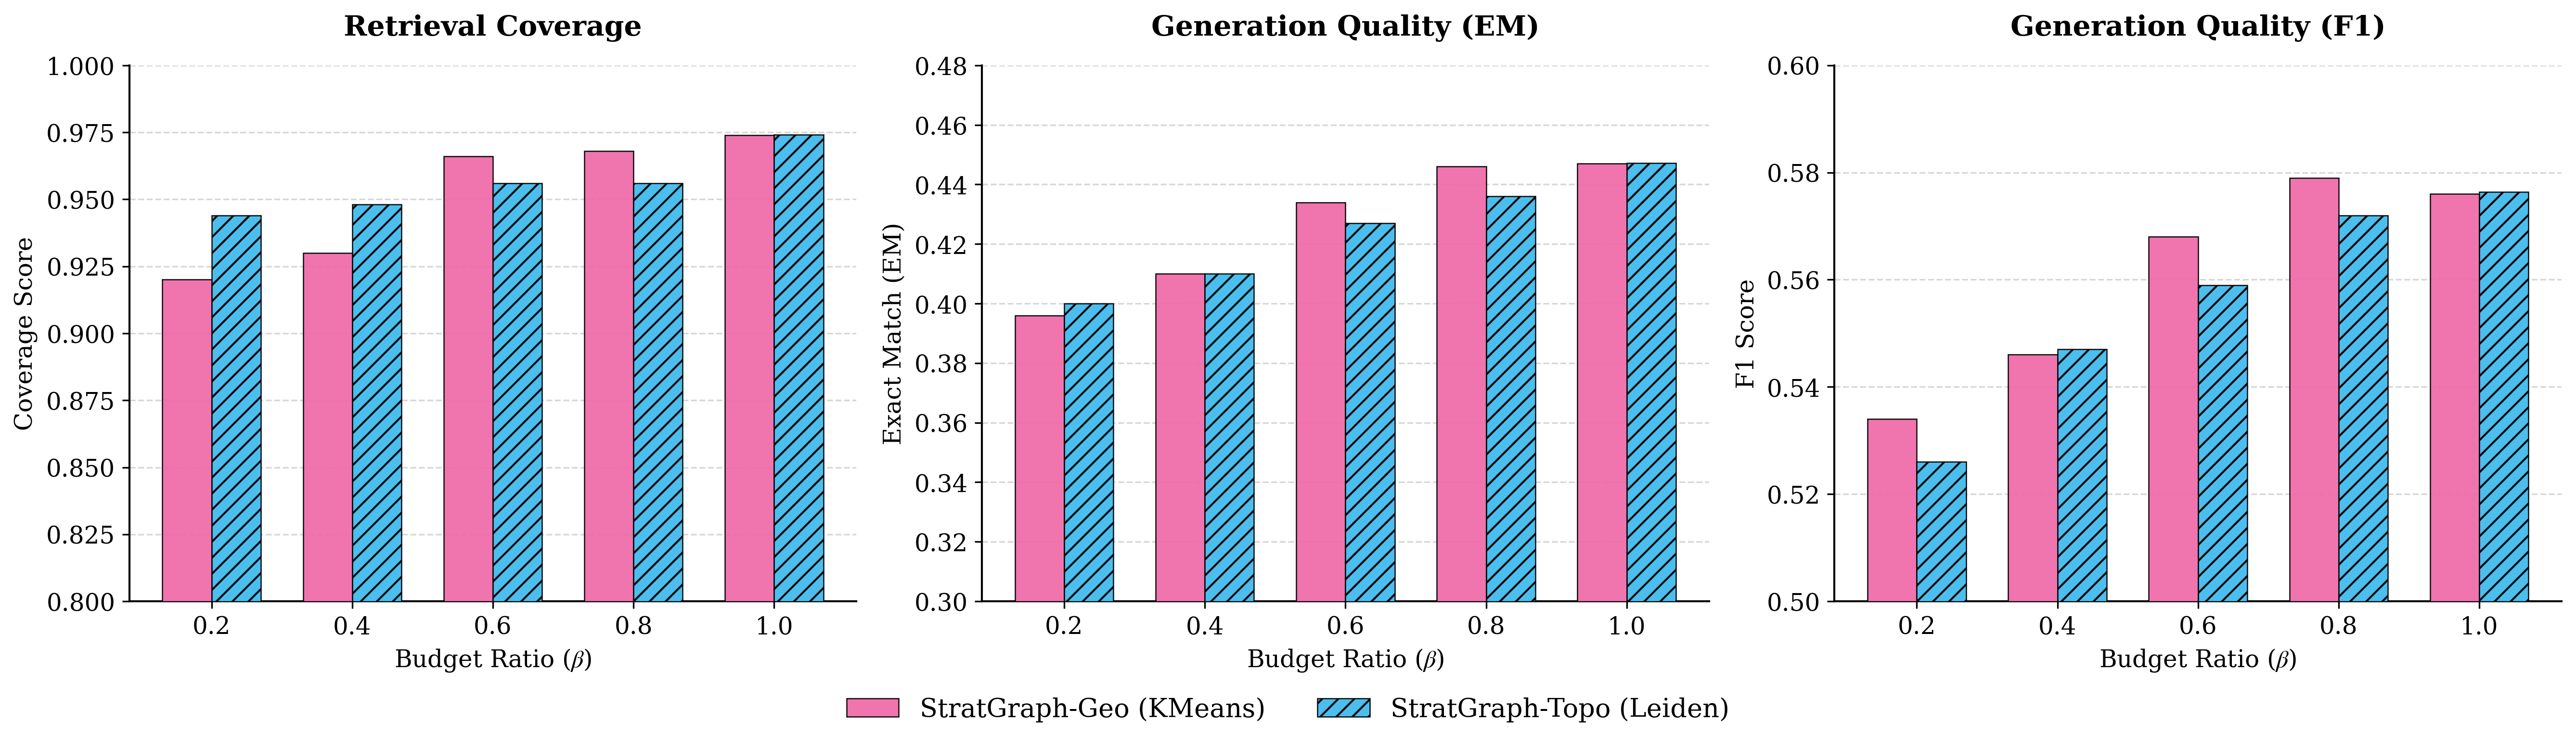

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. 数据准备 (Data Preparation)
# ==========================================
beta = np.array([0.2, 0.4, 0.6, 0.8, 1.0])

# KMeans (StratGraph-Geo) 数据
kmeans_cov = [0.9200, 0.9300, 0.9660, 0.9680, 0.9740]
kmeans_em  = [0.3960, 0.4100, 0.4340, 0.4460, 0.4470]
kmeans_f1  = [0.5340, 0.5460, 0.5680, 0.5790, 0.5760]

# Leiden (StratGraph-Topo) 数据
leiden_cov = [0.9440, 0.9480, 0.9560, 0.9560, 0.9742]
leiden_em  = [0.4000, 0.4100, 0.4270, 0.4360, 0.4471]
leiden_f1  = [0.5260, 0.5470, 0.5590, 0.5720, 0.5764]

# ==========================================
# 2. 样式与字体修复 (Style & Font Fix)
# ==========================================
# 字体设置：设置字体列表，如果找不到 Times New Roman，自动回退到 Matplotlib 自带的衬线字体
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman', 'Times', 'DejaVu Serif', 'Liberation Serif', 'serif']
plt.rcParams['mathtext.fontset'] = 'stix'  # 让数学公式渲染得像 LaTeX (Times 风格)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 1.0

# 配色方案 (低饱和度/莫兰迪色系 - 更加柔和专业)
# 方案 A: 雾霾蓝 + 铁锈红 (推荐)
# color_kmeans = '#6D96AB'  # Muted Blue (低饱和蓝)
# color_leiden = '#C67D78'  # Dusty Red (低饱和红)

# 如果您想要其他方案，可以取消注释下面这组：
# 方案 B: 灰蓝色 + 鼠尾草绿
color_kmeans = '#F06CA9' 
color_leiden = '#42BBEC' 

# ==========================================
# 3. 绘图逻辑 (Plotting)
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=300)

x = np.arange(len(beta))
width = 0.35

def plot_metric(ax, data1, data2, title, ylabel, ylim=None):
    # 绘制柱子 (调整了 alpha 透明度和 linewidth)
    rects1 = ax.bar(x - width/2, data1, width, label='StratGraph-Geo (KMeans)', 
                    color=color_kmeans, edgecolor='black', linewidth=0.6, alpha=0.95, zorder=3)
    
    # Leiden 组加上纹理，增强对比
    rects2 = ax.bar(x + width/2, data2, width, label='StratGraph-Topo (Leiden)', 
                    color=color_leiden, edgecolor='black', linewidth=0.6, alpha=0.95, hatch='///', zorder=3)
    
    # 标题和标签
    ax.set_title(title, fontweight='bold', fontsize=14, pad=15)
    ax.set_xlabel(r'Budget Ratio ($\beta$)', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=12)
    
    # X轴刻度
    ax.set_xticks(x)
    ax.set_xticklabels([str(b) for b in beta])
    
    # 优化网格线 (置于底层 zorder=0)
    ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#B0B0B0', zorder=0)
    
    if ylim:
        ax.set_ylim(ylim)
    else:
        ax.set_ylim(0, max(max(data1), max(data2)) * 1.15)
        
    # 去除多余边框
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    return rects1, rects2

# 绘制三个子图
# Coverage (Y轴保持您的数据范围)
plot_metric(axes[0], kmeans_cov, leiden_cov, 
            'Retrieval Coverage', 'Coverage Score', ylim=(0.8, 1.0)) 

# Exact Match (EM)
plot_metric(axes[1], kmeans_em, leiden_em, 
            'Generation Quality (EM)', 'Exact Match (EM)', ylim=(0.3, 0.48))

# F1 Score
plot_metric(axes[2], kmeans_f1, leiden_f1, 
            'Generation Quality (F1)', 'F1 Score', ylim=(0.5, 0.6))

# ==========================================
# 4. 图例与保存
# ==========================================
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=2, 
           bbox_to_anchor=(0.5, -0.05), frameon=False, fontsize=13)

plt.tight_layout()
plt.subplots_adjust(bottom=0.15)

# 保存
plt.savefig('result_bar_chart_low_sat.pdf', bbox_inches='tight')
plt.savefig('result_bar_chart_low_sat.png', bbox_inches='tight', dpi=300)
plt.show()